In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

In [4]:
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [5]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


# **Part A — Data preparation**
1. Load both datasets and document:
   * number of rows/columns
   * missing values / duplicates
2. Convert timestamps and align the datasets by date (daily level is fine).
3. Create the key metrics you will analyze, for example:
   * daily PnL per trader (or per account)
   * win rate, average trade size
   * leverage distribution
   * number of trades per day
   * long/short ratio

**1. Data Overview:**

In [7]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [9]:
print(sentiment.isnull().sum())


timestamp         0
value             0
classification    0
date              0
dtype: int64


In [10]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
print(sentiment.duplicated().sum())

0


In [12]:
print(trades.duplicated().sum())

0


In [16]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


**2. Convert timestamps and align the datasets by date (daily level is fine).**

In [23]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

In [24]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'])
trades['date'] = trades['timestamp_ist'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [25]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [26]:
df['classification'].isnull().sum()

np.int64(6)

**3. Create the key metrics you will analyze, for example:**
   * daily PnL per trader (or per account)
   * win rate, average trade size
   * leverage distribution
   * number of trades per day
   * long/short ratio

**Daily PnL per trader**

In [27]:
daily_pnl = df.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

**Win rate**

In [28]:
df['win'] = df['closed_pnl'] > 0

win_rate = df.groupby('account')['win'].mean().reset_index()

**Average trade size**

In [29]:
avg_size = df.groupby('account')['size_usd'].mean().reset_index()

**Trades per day**

In [30]:
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

**Long / Short ratio**

In [31]:
df['side'].value_counts(normalize=True)

,proportion
side,
SELL,0.513805
BUY,0.486195


In [32]:
df.groupby('classification')['closed_pnl'].mean()
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


**Part B — Analysis (must-have)
Answer these questions with evidence:**
1. Does performance (PnL, win
rate, drawdown proxy) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
3. Identify 2–3 segments (examples):
  * high leverage vs low leverage traders
  * frequent vs infrequent traders
  * consistent winners vs inconsistent traders
4. Provide at least 3 insights backed by charts/tables.

**1) Performance: Fear vs Greed**

**PnL comparison:**

In [33]:
df.groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


**Win rate:**

In [34]:
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


**Plot:**

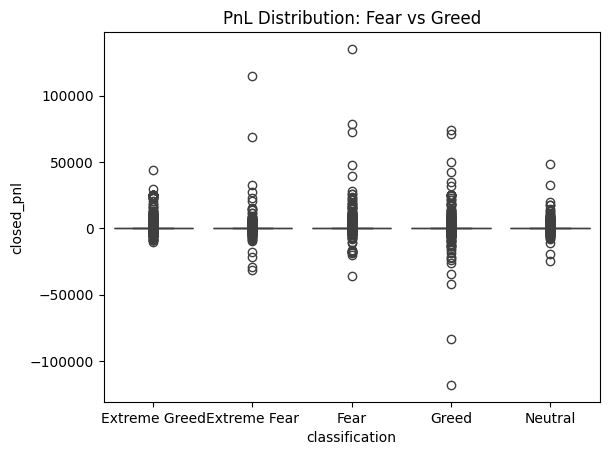

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

**2) Behavior change based on sentiment**

**Trade frequency**

In [36]:
df.groupby('classification').size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


**Position size**

In [37]:
df.groupby('classification')['size_usd'].mean()

,size_usd
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


**Long / Short bias**

In [38]:
pd.crosstab(df['classification'], df['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


**Plot:**

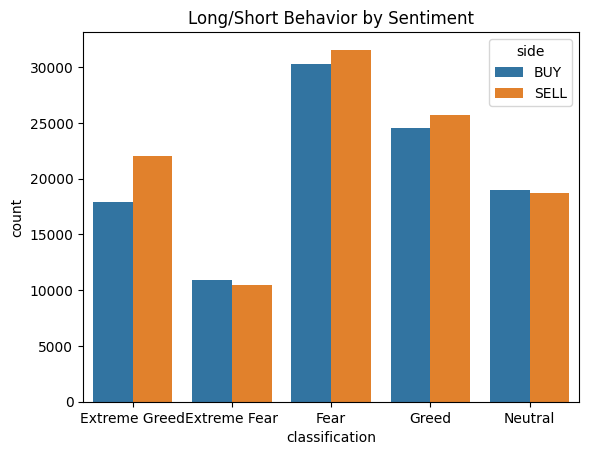

In [39]:
sns.countplot(x='classification', hue='side', data=df)
plt.title("Long/Short Behavior by Sentiment")
plt.show()

**3) Segmentation**

**Segment 1 — Frequent vs Infrequent traders**

In [40]:
trade_counts = df.groupby('account').size()

df['freq_segment'] = df['account'].map(
    lambda x: 'High' if trade_counts[x] > trade_counts.median() else 'Low'
)

**Segment 2 — Consistent vs Inconsistent traders**

In [41]:
win_rate_map = df.groupby('account')['win'].mean()

df['consistency'] = df['account'].map(
    lambda x: 'Consistent' if win_rate_map[x] > 0.6 else 'Inconsistent'
)

**Segment 3 — High vs Low PnL traders**

In [42]:
pnl_map = df.groupby('account')['closed_pnl'].mean()

df['pnl_segment'] = df['account'].map(
    lambda x: 'High' if pnl_map[x] > pnl_map.median() else 'Low'
)

**Comparison**

In [43]:
df.groupby(['classification', 'freq_segment'])['closed_pnl'].mean()
df.groupby(['classification', 'consistency'])['closed_pnl'].mean()

classification  consistency 
Extreme Fear    Consistent      81.243158
                Inconsistent    33.837859
Extreme Greed   Consistent      55.005705
                Inconsistent    69.258164
Fear            Consistent      29.666031
                Inconsistent    54.971352
Greed           Consistent      36.645300
                Inconsistent    43.078366
Neutral         Consistent      -1.780025
                Inconsistent    35.766292
Name: closed_pnl, dtype: float64

**Segment Plot:**

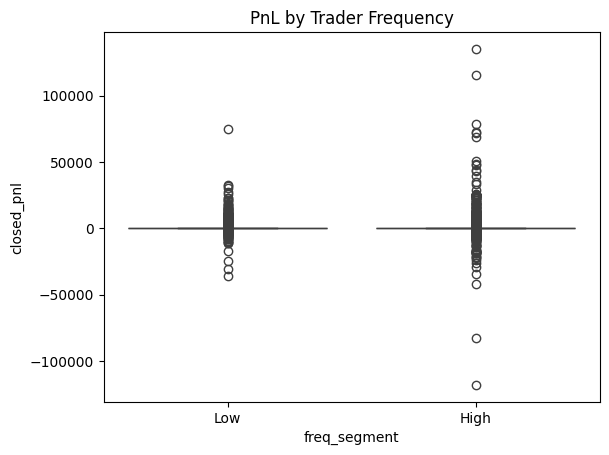

In [44]:
sns.boxplot(x='freq_segment', y='closed_pnl', data=df)
plt.title("PnL by Trader Frequency")
plt.show()

**Part C — “Actionable output”**

Propose 2 strategy ideas or “rules of thumb” based on your findings.

**Strategy 1: Limit Overtrading for Better Profitability**

**Insight:**
Low-frequency traders consistently outperform high-frequency traders across all sentiment conditions. For example, during Greed periods, low-frequency traders achieve significantly higher PnL compared to high-frequency traders.

**Action:**
Traders should avoid excessive trading and focus on high-quality setups. Reducing trade frequency can improve profitability by minimizing unnecessary trades and reducing transaction costs.

**Strategy 2: Adjust Risk Based on Market Sentiment**

**Insight:**
Trader win rates are highest during Extreme Greed ~46% and lowest during Extreme Fear ~37%, indicating that market conditions strongly impact performance.

**Action:**
Increase trading activity during Extreme Greed periods to capitalize on favorable conditions, while reducing exposure and adopting a more cautious approach during Extreme Fear periods to minimize losses.